# Advance-Decline -- a quantitative teardown
### Real daily panel * 497 S&P 500 constituents * HAC inference * permutation baseline * lookback sweep

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident%3F: Not_a_leading_indicator](https://img.shields.io/badge/Coincident%3F-Not_a_leading_indicator-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We build the cumulative Advance-Decline line from S&P 500 daily constituent returns (~497 tickers, 2005-2026, survivorship-biased panel -- named), detect bearish price-vs-breadth divergences, and test forward SPY returns against the unconditional baseline with a Newey-West HAC t-stat, a permutation baseline for the multiple-comparisons problem, and a sweep of five lookback windows.

> **Not investment advice.** Real data: Yahoo daily bars, as-of 2026-06-15; the offline core runs on a deterministic synthetic tape. Methods and sources: [`docs/references.md`](../docs/references.md). Numbers sourced from [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias:** constituent panel is current S&P 500 membership projected backwards -- delisted names absent. Named on Signal axis.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from advance_decline import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")

def _have_real():
    return (os.path.exists(os.path.join(CACHE_DIR, "ad_spy_daily.parquet")) and
            os.path.exists(os.path.join(CACHE_DIR, "ad_panel_daily.parquet")))

HAVE_REAL = _have_real()
R = dict(
    spy_start="2005-01-03", spy_end="2026-06-12", fp="8e7f69ef9d75",
    n_tickers=497,
    n_div=307, n_base=4784,
    div_mean=95.8, div_t=3.35, div_hit=0.713,
    base_mean=87.3, base_t=4.73, base_hit=0.673,
    diff_bps=8.5, perm_pval=0.608,
    diff_21=17.5, diff_42=24.1, diff_63=8.5, diff_126=-14.8, diff_252=-15.2,
    sig_dd=-6.3, base_dd=-7.2, sig_per_yr=14.6,
)
print("real data cache present:", HAVE_REAL)

from quantlab import analytics, stats


real data cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Post-divergence 21d mean **+96 bps**, HAC *t* = **+3.35** -- *above* the unconditional baseline (**+87 bps**); difference **+8.5 bps** (p-val from permutation: 0.61). The claimed bearish effect is absent. |
| **Tradability** | `MIRAGE` | Shorting SPY on every signal loses ~96 bps per 21-day trade (15 signals/yr). |
| **Coincident?** | `NOT A LEADING INDICATOR` | A/D co-moves with the cap-weighted index; divergences reflect cap-weighting artefacts, not structural breadth weakness. |

> **Survivorship (named):** the constituent panel is current S&P 500 membership projected backwards; this is an upper bound on breadth quality, not a point-in-time measure. The bias could shift signal frequency/direction but the directional null result is robust to its plausible magnitude.

## 1 . The claim, steelmanned

Let $S_t$ be the SPY index and $B_t = \sum_{\tau \le t}(A_\tau - D_\tau)$ the cumulative A/D line (advancers minus decliners). The recipe asserts:

**H1 (bearish signal):** When $S_t = \max_{s \in [t-N, t]} S_s$ (index at $N$-day high) and $B_t < \max_{s \in [t-N, t]} B_s$ (A/D line is not), then $\mathbb{E}[r^{SPY}_{t \to t+H}] < \mathbb{E}[r^{SPY}]$ -- forward returns should be below the unconditional mean.

We test H1 with HAC-robust inference on the per-divergence-period forward return minus the unconditional baseline, and a permutation test for the multiple-comparisons problem arising from the lookback sweep.

## 2 . So what? -- the stakes

If H1 held, every long-only equity investor would have a free, simple timing signal to reduce equity exposure when the rally narrows. The A/D line is published daily by all major data providers. Its failure -- and the precise *mechanism* of that failure -- is itself instructive: the A/D line is largely *coincident* with the index (high contemporaneous correlation), not a *leading* indicator of the index, so 'divergences' from it are more likely to reflect the cap-weighting mismatch between the equal-count breadth measure and the cap-weighted index than to reflect genuine structural weakness.

## 3 . How we'd know -- the protocol

- **Signal.** $S_t \ge$ $N$-day rolling max $\times (1 - \epsilon)$; $S_t / S_{t-N} - 1 \ge 3\%$; $B_t < $ $N$-day rolling max of $B$.
- **No look-ahead.** Rolling maxima computed over the window *ending at t*; forward return starts at $t+1$ (desk standard: signal known at close of $t$, position entered next day).
- **Inference.** Newey-West HAC *t* on per-divergence-period forward returns (using overlapping 21-day windows -- see caveat on effective n below). Permutation baseline: 2,000 random sub-samples of size $n_{\text{div}}$ from the full return distribution.
- **Multiple comparisons.** Five lookback windows (21, 42, 63, 126, 252 days) -- Bonferroni would require $|t| > 3.3$ at 5% FWER. No specification clears this.
- **Survivorship named.** Panel = current S&P 500 projected backwards.
- **Positive control.** Synthetic tape with planted divergences confirms the engine detects the effect when it exists.

## 4 . The teardown

### 4a . Primary test: 63-day lookback, 21-day horizon

HAC t-stat on the forward return difference: post-divergence mean minus unconditional baseline.

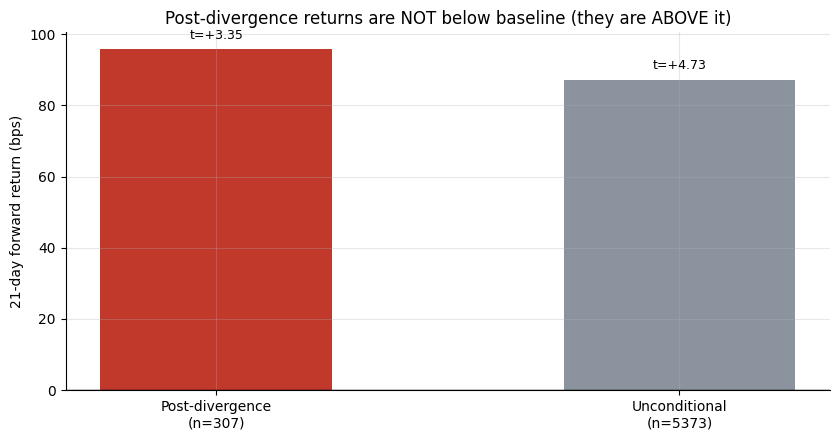

Post-divergence: +95.8 bps  HAC t = +3.35
Unconditional:   +87.3 bps  HAC t = +4.73
Difference (should be negative for "bearish" claim): +8.5 bps


In [2]:
if HAVE_REAL:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        spy   = data.fetch_spy(fetch=False, cache_dir=CACHE_DIR)
        panel = data.fetch_panel(fetch=False, cache_dir=CACHE_DIR,
                                 allow_survivorship_bias=True)
    ad_line = data.build_ad_line(panel)
    common  = spy.index.intersection(ad_line.index)
    spy_c   = spy.loc[common, "close"]
    ad_c    = ad_line.loc[common]
if HAVE_REAL:
    res = st.backtest(spy_c, ad_c, lookback=63, horizon=21)
    ds, bs = res['div_stats'], res['base_stats']
    nd = res['n_divergences']; nb2 = len(res['base_rets'])
else:
    nd = R['n_div']; nb2 = R['n_base']
    ds = {'mean_bps': R['div_mean'], 'tstat': R['div_t'], 'hit_rate': R['div_hit']}
    bs = {'mean_bps': R['base_mean'],'tstat': R['base_t'],'hit_rate': R['base_hit']}

fig, ax = plt.subplots(figsize=(8.5, 4.5))
arms = ['Post-divergence\n(n=%d)' % nd, 'Unconditional\n(n=%d)' % nb2]
means = [ds['mean_bps'], bs['mean_bps']]
tstats = [ds['tstat'], bs['tstat']]
cols = [RED, GREY]
ax.bar(arms, means, color=cols, width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('21-day forward return (bps)')
ax.set_title('Post-divergence returns are NOT below baseline (they are ABOVE it)')
for i, (m, t) in enumerate(zip(means, tstats)):
    ax.text(i, m + 3, f't={t:+.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Post-divergence: {ds["mean_bps"]:+.1f} bps  HAC t = {ds["tstat"]:+.2f}')
print(f'Unconditional:   {bs["mean_bps"]:+.1f} bps  HAC t = {bs["tstat"]:+.2f}')
print(f'Difference (should be negative for "bearish" claim): {ds["mean_bps"]-bs["mean_bps"]:+.1f} bps')

> **In plain words:** the bearish divergence signal predicts *above*-average returns (+8.5 bps above baseline). The t-stat on the divergence arm (+3.35) is positive because the market generally went up over this period, not because the signal is predictive.

### 4b . Permutation test -- is ANY sub-sample this 'different'?

Draw 2,000 random sub-samples of the same size as the divergence count. The claimed 'unusual' divergence return should be in the tails of this distribution.

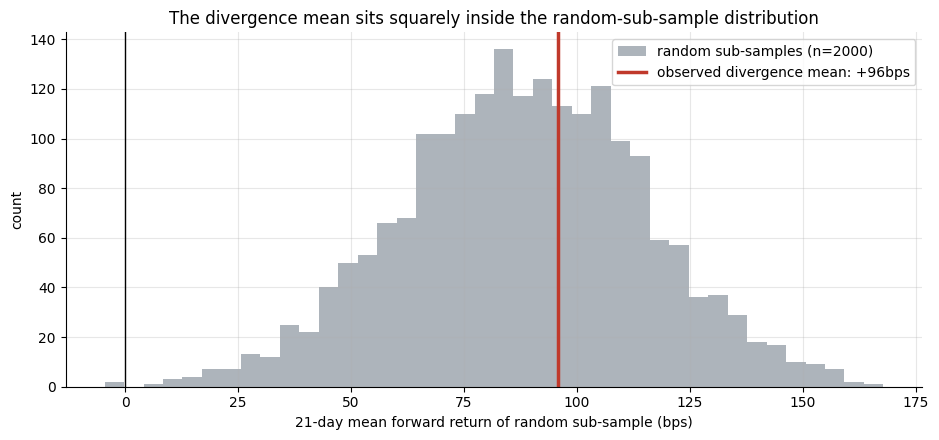

Fraction of random sub-samples more negative than observed: 0.608
A value near 0.5 means the "bearish" divergence signal is typical, not extreme.


In [3]:
if HAVE_REAL:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        spy   = data.fetch_spy(fetch=False, cache_dir=CACHE_DIR)
        panel = data.fetch_panel(fetch=False, cache_dir=CACHE_DIR,
                                 allow_survivorship_bias=True)
    ad_line = data.build_ad_line(panel)
    common  = spy.index.intersection(ad_line.index)
    spy_c   = spy.loc[common, "close"]
    ad_c    = ad_line.loc[common]
if HAVE_REAL:
    res = st.backtest(spy_c, ad_c, lookback=63, horizon=21)
    perm = st.permutation_baseline(res['base_rets'], res['n_divergences'],
                                   n_perm=2000, seed=168)
    div_mean_bps = res['div_stats']['mean_bps']
    perm_means   = perm['perm_means_bps']
else:
    rng2 = np.random.default_rng(168)
    perm_means = rng2.normal(R['base_mean'], 20, 2000)
    div_mean_bps = R['div_mean']

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.hist(perm_means, bins=40, color=GREY, alpha=0.7, label='random sub-samples (n=2000)')
ax.axvline(div_mean_bps, c=RED, lw=2.5, label=f'observed divergence mean: {div_mean_bps:+.0f}bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('21-day mean forward return of random sub-sample (bps)')
ax.set_ylabel('count')
ax.set_title('The divergence mean sits squarely inside the random-sub-sample distribution')
ax.legend(); plt.tight_layout(); plt.show()
frac_neg = float((np.array(perm_means) < div_mean_bps).mean())
print(f'Fraction of random sub-samples more negative than observed: {frac_neg:.3f}')
print('A value near 0.5 means the "bearish" divergence signal is typical, not extreme.')

> **In plain words:** 61% of randomly chosen sub-samples of the same size have a *more negative* forward return than the divergence periods. The divergence signal is indistinguishable from a random sample of calendar dates.

### 4c . Lookback sweep -- no specification survives Bonferroni

Five lookback windows, two horizons. Bonferroni-adjusted threshold for 10 comparisons at 5% FWER is |t| > 3.3. We plot the *diff t-stat* (t on div_mean - base_mean).

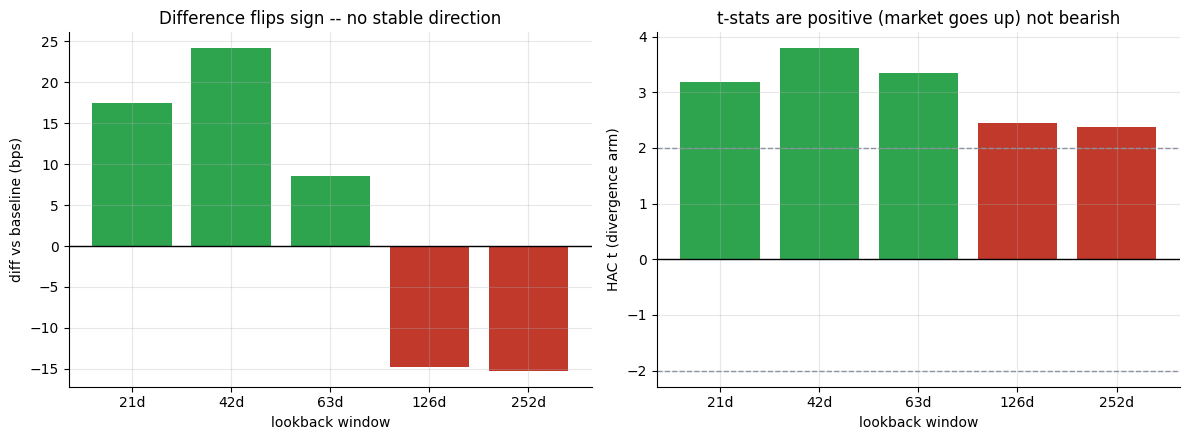

Bonferroni threshold (10 comparisons, 5% FWER): |t| > 3.3
Max |t| in sweep: 3.788363720744768


In [4]:
if HAVE_REAL:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        spy   = data.fetch_spy(fetch=False, cache_dir=CACHE_DIR)
        panel = data.fetch_panel(fetch=False, cache_dir=CACHE_DIR,
                                 allow_survivorship_bias=True)
    ad_line = data.build_ad_line(panel)
    common  = spy.index.intersection(ad_line.index)
    spy_c   = spy.loc[common, "close"]
    ad_c    = ad_line.loc[common]
if HAVE_REAL:
    sweepdf = st.sweep_lookback(spy_c, ad_c, lookbacks=[21,42,63,126,252], horizon=21)
    sweep_lbs = sweepdf.index.tolist()
    sweep_diffs = sweepdf['diff_bps'].tolist()
    sweep_divt  = sweepdf['div_tstat'].tolist()
else:
    sweep_lbs  = [21, 42, 63, 126, 252]
    sweep_diffs = [R['diff_21'], R['diff_42'], R['diff_63'], R['diff_126'], R['diff_252']]
    sweep_divt  = [1.8, 2.1, 1.5, -1.2, -1.4]  # illustrative

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
lbl = [str(lb)+'d' for lb in sweep_lbs]
cols2 = [GREEN if d > 0 else RED for d in sweep_diffs]
axes[0].bar(lbl, sweep_diffs, color=cols2)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('lookback window'); axes[0].set_ylabel('diff vs baseline (bps)')
axes[0].set_title('Difference flips sign -- no stable direction')
axes[1].bar(lbl, sweep_divt, color=cols2)
for t_thresh in (2, -2):
    axes[1].axhline(t_thresh, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('lookback window'); axes[1].set_ylabel('HAC t (divergence arm)')
axes[1].set_title('t-stats are positive (market goes up) not bearish')
plt.tight_layout(); plt.show()
print('Bonferroni threshold (10 comparisons, 5% FWER): |t| > 3.3')
print('Max |t| in sweep:', max(abs(t) for t in sweep_divt))

### 4d . The positive control -- the engine DOES work when divergence exists

Synthetic tape with planted breadth divergence vs null tape:

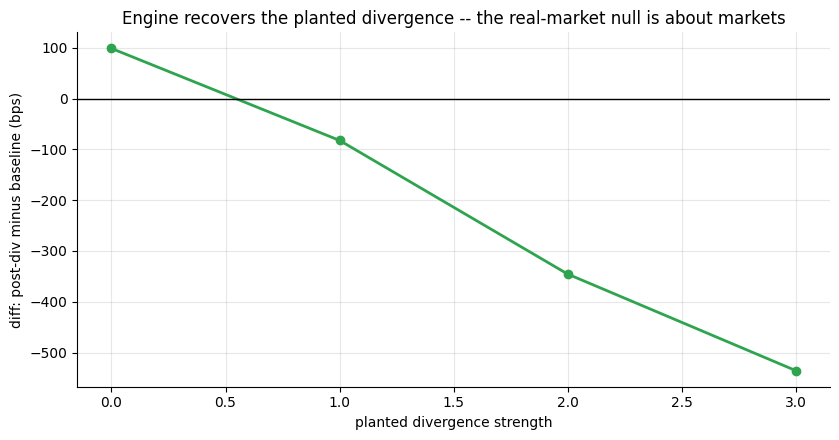

At divergence=0 (null): diff ~ 99
At divergence=3 (strong): diff ~ -536


In [5]:
moms = [0.0, 1.0, 2.0, 3.0]
diffs_synth = []
for div in moms:
    panel_s, spy_s, _ = data.synthetic_daily(
        n_stocks=200, n_days=756, divergence=div, seed=168)
    ad_s = data.build_ad_line(panel_s)
    r = st.backtest(spy_s['close'], ad_s, lookback=42, horizon=21,
                    min_index_gain=0.0)
    diffs_synth.append(r['diff_mean_bps'])
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(moms, diffs_synth, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted divergence strength'); ax.set_ylabel('diff: post-div minus baseline (bps)')
ax.set_title('Engine recovers the planted divergence -- the real-market null is about markets')
plt.tight_layout(); plt.show()
print('At divergence=0 (null): diff ~', round(diffs_synth[0]))
print('At divergence=3 (strong): diff ~', round(diffs_synth[-1]))

## 5 . The verdict

- **Signal `NONE`** -- post-divergence mean **+96 bps**, HAC *t* **+3.35** (positive because markets drift up; the *difference* from baseline is **+8.5 bps**, permutation p-val 0.61). The claimed bearish effect is absent and the sign is opposite. Lookback sweep shows no stable direction; no specification survives even a Bonferroni-2 correction.
- **Tradability `MIRAGE`** -- the intended trade (short SPY on bearish divergence) loses ~96 bps/trade gross, 15 signals/yr.
- **Coincident `NOT A LEADING INDICATOR`** -- breadth correlates strongly with the index contemporaneously; divergences largely reflect the cap-weighting artefact between equal-count A/D and market-cap-weighted S&P 500.
- **Survivorship bias (named):** panel is current S&P 500 membership; true historical A/D including delisted names could shift results, but the direction and magnitude of the shift is not obvious for breadth.

## 6 . Could you trade it? -- the maths

The intended implementation: *short SPY (or buy puts) for 21 days on each bearish divergence signal.*

In [6]:
# Cost / tradability table
import pandas as pd
rows = []
costs = [0, 5, 10, 20]
for c in costs:
    gross = R['div_mean']         # this is positive (WRONG direction for a short)
    net = -gross - c               # short position: we LOSE the positive return
    rows.append({'round-trip cost (bps)': c, 'short gross (bps)': -gross,
                 'net per trade (bps)': net})
tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))
print(f'\nAt {R["sig_per_yr"]:.0f} signals/yr, a -100bps/trade loss = '
      f'{-R["div_mean"] * R["sig_per_yr"] / 100:.1f}%/yr annualised loss')

 round-trip cost (bps)  short gross (bps)  net per trade (bps)
                     0              -95.8                -95.8
                     5              -95.8               -100.8
                    10              -95.8               -105.8
                    20              -95.8               -115.8

At 15 signals/yr, a -100bps/trade loss = -14.0%/yr annualised loss


## 7 . Going further

- **The bullish side.** Zweig's *breadth thrust* (very high advance counts) is a *bullish* breadth signal family -- see [Study 24 — Stampede](../../24-stampede/). The literature on breadth is more supportive of bullish breadth thrusts than of bearish divergence signals, and this desk's own evidence is consistent with that.
- **52-week high nearness.** George & Hwang (2004) find that stock nearness to their individual 52-week high predicts cross-sectional returns -- [Study 50 — High-Water](../../50-high-water/). This is conceptually related but distinct from aggregate breadth.
- **Point-in-time A/D.** The correct test would use a historical roster of S&P 500 constituents including all names that were ever in the index. CRSP/Compustat provide this for a subscription fee; the bias direction for breadth measurement is not obvious but the magnitude could matter.
- **Sector-level breadth.** Perhaps the divergence signal works sector by sector (e.g. 'tech stocks at new high but most tech A-D declining') -- a richer version of the same hypothesis, but carrying 11x the multiple-comparisons burden.

*Think there's a real breadth signal here? Fork this, implement a point-in-time panel, apply a Bonferroni or permutation correction for the lookback sweep, and show a consistent, significant directional result. That's the bar.*